# Brain plotting with NiSpace

NiSpace provides two standalone brain plotting functions from `nispace.plotting` that can be used independently of any colocalization analysis:

- `brainplot()` — renders parcellated DataFrames, NIfTI volumes, or GIfTI surface images on glass brains, anatomical slices, or inflated cortical surfaces.
- `view_surf()` — interactive 3D surface viewer (based on nilearn's `view_surf`).

These are the same functions that `nsp.plot_brain()` uses internally. Here we show how to use them directly, which is useful whenever you have brain maps to visualize outside of a NiSpace workflow — for example, for quality control, figure preparation, or just exploring a dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nispace.plotting import brainplot, view_surf
from nispace.datasets import fetch_reference, fetch_example, fetch_parcellation
from nispace.io import load_img

## `brainplot()` basics

The simplest use case: pass a NIfTI image and you get a plot. No parcellation needed.

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

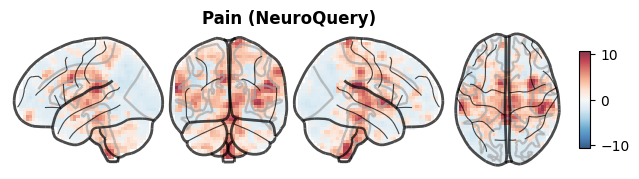

In [2]:
# load the pain map (a NIfTI image)
pain_map = load_img("neuroquery/pain.nii.gz")

# plot it — default rendering is glass brain for volumetric images
brainplot(pain_map, title="Pain (NeuroQuery)")

## Parcellated data

When you have parcellated data (a DataFrame or Series), pass the parcellation name or image alongside the data. NiSpace maps the parcel values back onto the brain.

INFO | 23/05/26 10:54:51 | nispace.datasets: Loading pet maps.
INFO | 23/05/26 10:54:51 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 23/05/26 10:54:51 | nispace.datasets: Filtering maps by collection.
INFO | 23/05/26 10:54:51 | nispace.datasets: Loading data parcellated with 'Schaefer200'
INFO | 23/05/26 10:54:51 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:54:51 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/05/26 10:54:51 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 23/05/26 10:54:51 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 23/05/26 10:54:51 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 23/05/26 10:54:52 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

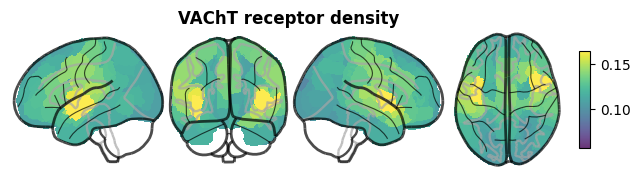

In [3]:
# fetch some PET maps, already parcellated
pet = fetch_reference("pet", parcellation="Schaefer200",
                      collection="UniqueTracers", print_references=False)

# plot a single map (select a Series by map-level name)
vacht = pet.loc[pet.index.get_level_values("map").str.contains("VAChT")].squeeze()

brainplot(vacht, parcellation="Schaefer200",
          title="VAChT receptor density", symmetric_cmap=False)

Opioid maps: ['target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020', 'target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018', 'target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015']
INFO | 23/05/26 10:54:55 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:54:55 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/05/26 10:54:55 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 23/05/26 10:54:55 | nispace.plotting: brainplot: threshold='auto' → 0.008912142366170883
INFO | 23/05/26 10:54:55 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 23/05/26 10:54:56 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym'.
INFO | 23/05/26 10:54:56 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLi

(<Figure size 2160x180 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

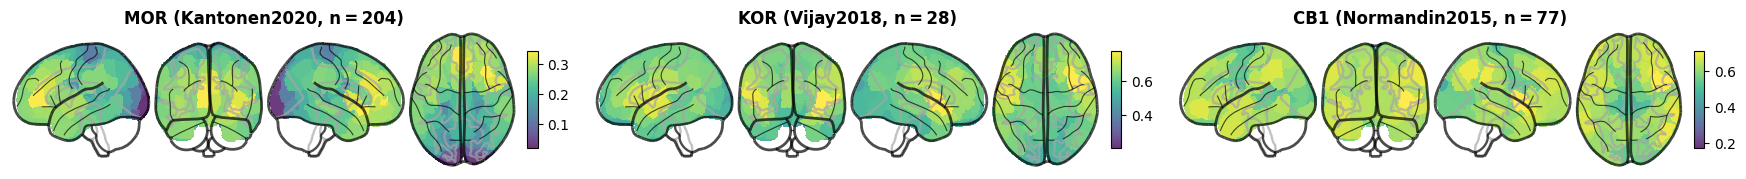

In [4]:
# plot multiple maps from a DataFrame
# select the opioid/endocannabinoid system maps
opioid_maps = pet.loc["Opiods/Endocannabinoids"]
print(f"Opioid maps: {list(opioid_maps.index)}")

brainplot(
    opioid_maps,
    parcellation="Schaefer200",
    symmetric_cmap=False,
    shared_colorscale=False,
    ncols=3
)

Important for use of our brain plot routines outside of the NiSpace colocalization workflow: You can also pass a custom parcellation (file/path) and the parcellated vector.

INFO | 23/05/26 10:55:07 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:55:07 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/05/26 10:55:07 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 23/05/26 10:55:07 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
Parcellation nifti: <class 'nibabel.nifti1.Nifti1Image'>
Parcellated vector: <class 'pandas.core.series.Series'> (200,)
INFO | 23/05/26 10:55:07 | nispace.core.parcellation: Building Parcellation from path / image.
INFO | 23/05/26 10:55:07 | nispace.core.parcellation: Parcellation space: 'mni152'.
INFO | 23/05/26 10:55:07 | nispace.core.parcellation: Parcellation 'None': validation passed.
INFO | 23/05/26 10:55:07 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 23/05/26 10:55:07 | nispace.plotting: b

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

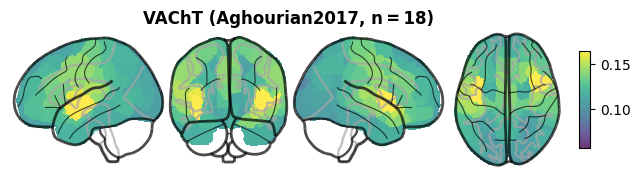

In [5]:
# load a NiSpace parcellation nifti directly (so, brainplot will not know it's an internal one)
parc_nifti = fetch_parcellation("Schaefer200").get_image("MNI152NLin2009cAsym")
print("Parcellation nifti:", type(parc_nifti))

# we already have the vector
print("Parcellated vector:", type(vacht), vacht.shape)

# plot
brainplot(vacht, parcellation=parc_nifti)

This works with a 2-tuple of gifti files, too!

Parcellation giftis: <class 'tuple'>
INFO | 23/05/26 10:55:11 | nispace.core.parcellation: Building Parcellation from path / image.
INFO | 23/05/26 10:55:11 | nispace.core.parcellation: Parcellation space: 'fsLR'.
INFO | 23/05/26 10:55:11 | nispace.core.parcellation: Parcellation 'None': validation passed.
INFO | 23/05/26 10:55:11 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 23/05/26 10:55:11 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsLR', mni_space='None', surf_mesh='inflated'


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

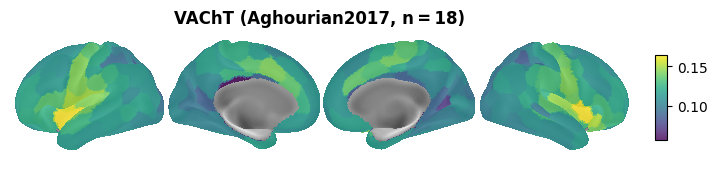

In [6]:
# load parcellation gifti files directly
parc_giftis = fetch_parcellation("Schaefer200", verbose=False).get_image("fsLR")
print("Parcellation giftis:", type(parc_giftis))

# plot
brainplot(vacht, parcellation=parc_giftis, space="fsLR")

## Rendering modes

The `kind` argument controls how the brain is rendered.  

We currently have `"glass"`, `"slice"`, and `"surf"`.  
All these three options accept the `space` argument. For `"glass"` and `"slice"`, the two integrated MNI spaces are available (`"MNI152NLin2009cAsym"` and `"...6Asym"`); for `"surf"`, options are `"fsaverage"` and `"fsLR"` with their default meshes. Check the function reference for further information. 

These all use nilearn methods internally, but optimized for ease of use and very effective options to plot plot parcellated data. Also, every brain plot can easily be plotted into an axis as compared to only on figure level. If you are experienced with nilearn surface plotting, you might realize that the surfaces generate considerably faster. This is due to an internal tweak to nilearn's plot_surf function, improving array management.

### Glass brain plots

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

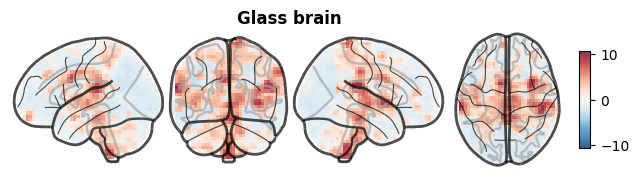

In [7]:
# glass brain (semi-transparent 3D volume)
brainplot(pain_map, kind="glass", title="Glass brain")

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

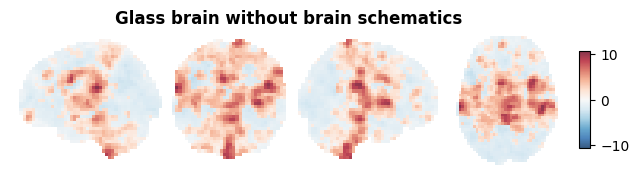

In [8]:
# we added a patch to turn of the actual glass brain schematics
# the result looks pretty similar to the old-school SPM glass brain
brainplot(pain_map, kind="glass", title="Glass brain without brain schematics", draw_brain=False)

### Slice plots

(<Figure size 700x180 with 7 Axes>, [<Axes: >])

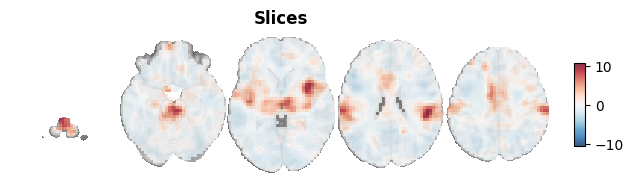

In [9]:
# anatomical slices
brainplot(pain_map, kind="slice", title="Slices")

(<Figure size 700x180 with 7 Axes>, [<Axes: >])

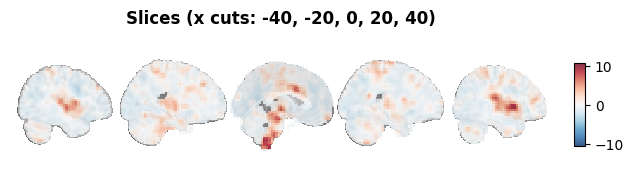

In [10]:
# the slice plots use nilearn.plotting.plot_img arguments for layout specification
brainplot(pain_map, kind="slice", title="Slices (x cuts: -40, -20, 0, 20, 40)", 
          display_mode="x", cut_coords=[-40, -20, 0, 20, 40])

### Surface plots

INFO | 23/05/26 10:55:24 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:55:24 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/05/26 10:55:24 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 23/05/26 10:55:24 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 23/05/26 10:55:24 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsaverage'.
INFO | 23/05/26 10:55:24 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'fsaverage'.
INFO | 23/05/26 10:55:24 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsaverage', mni_space='None', surf_mesh='inflated'


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

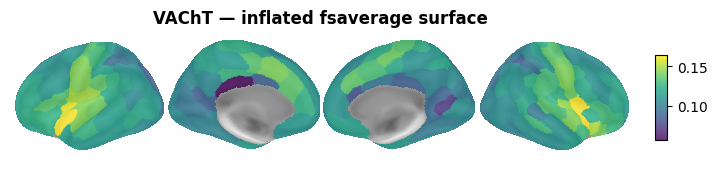

In [11]:
# inflated cortical surface (parcellated data), available: fsLR or fsaverage
brainplot(vacht, parcellation="Schaefer200",
          kind="surface", space="fsaverage", surf_mesh="inflated",
          symmetric_cmap=False, title="VAChT — inflated fsaverage surface")

INFO | 23/05/26 10:55:28 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:55:28 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/05/26 10:55:28 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 23/05/26 10:55:28 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 23/05/26 10:55:28 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 23/05/26 10:55:28 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'fsLR'.
INFO | 23/05/26 10:55:28 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsLR', mni_space='None', surf_mesh='midthickness'


(<Figure size 800x220 with 2 Axes>, [<Axes: >])

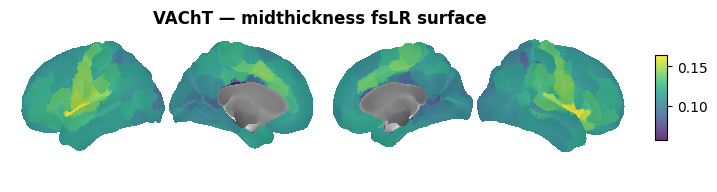

In [12]:
# fsLR midthickness surface
brainplot(vacht, parcellation="Schaefer200",
          kind="surface", space="fsLR", surf_mesh="midthickness",
          symmetric_cmap=False, title="VAChT — midthickness fsLR surface")

### Combined cortex-subcortex plots

TO BE IMPLEMENTED.

If you currently set `kind="combined"`, you will receive a `NotImplementedError`.  
In the future, we will have a special kind of plot that combined a surface at the top with a subcortical rendered volumetric, glassbrain, or slice representation at the bottom. This will work with integrated parcellations only and build specifically on the cortex-subcortex combination routine implemented in NiSpace.

INFO | 23/05/26 10:55:32 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:55:32 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/05/26 10:55:32 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 23/05/26 10:55:32 | nispace.plotting: brainplot: threshold='auto' → 0.10880859941244125
INFO | 23/05/26 10:55:32 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 23/05/26 10:55:32 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'fsLR'.
INFO | 23/05/26 10:55:32 | nispace.plotting: brainplot: kind='surface', img_mode='None', surf_space='fsLR', mni_space='None', surf_mesh='inflated'
INFO | 23/05/26 10:55:32 | nispace.core.parcellation: Building multi-space Parcellation for 'TianS2' from library.
INFO | 23/05/26 10:55:32 | nispace.core.parcellation: Available spaces: MNI152NLin

(<Figure size 800x320 with 6 Axes>, [<Axes: label='inset_axes'>])

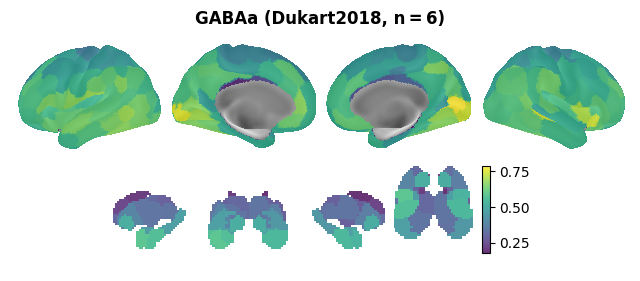

In [13]:
# here is a conceptual example of this will look like (of course more refined, more details, etc)

# cortex + subcortex data
gaba_cx = fetch_reference(
    "pet", maps="GABAa_", parcellation="Schaefer200", collection="UniqueTracers", verbose=False).squeeze()
gaba_sc = fetch_reference(
    "pet", maps="GABAa_", parcellation="TianS2", collection="UniqueTracers", verbose=False).squeeze()

# create layout
fig, ax = plt.subplots(1, figsize=(8, 3.2))
ax_cx = ax.inset_axes((0,   0.4, 1,   0.6))
ax_sc = ax.inset_axes((0.15, 0,   0.6, 0.5))
ax.set_axis_off()
ax_cx.set_axis_off()
ax_sc.set_axis_off()

# plot
vmin, vmax = min(gaba_cx.min(), gaba_sc.min()), max(gaba_cx.max(), gaba_sc.max())
brainplot(
    gaba_cx, parcellation="Schaefer200", kind="surface", space="fsLR", vmin=vmin, vmax=vmax,
    axes=ax_cx, fig=fig, colorbar=False, title_kwargs={"y": 1.1}
)
brainplot(
    gaba_sc, parcellation="TianS2", kind="glass", vmin=vmin, vmax=vmax, 
    axes=ax_sc, fig=fig, draw_brain=False, zoom=2.0, title=False
)

## Colormap and scale options

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

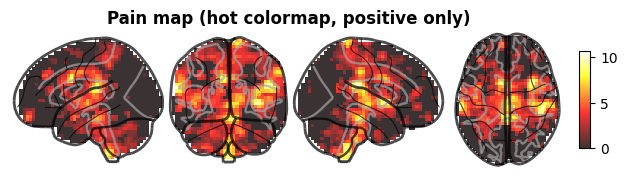

In [14]:
# custom colormap, threshold, and fixed scale
brainplot(
    pain_map,
    kind="glass",
    cmap="hot",
    symmetric_cmap=False,
    vmin=0,       # only show positive values
    threshold=0,  # explicitly threshold at 0
    title="Pain map (hot colormap, positive only)"
)

INFO | 23/05/26 10:55:40 | nispace.datasets: Loading enigmathick maps.
INFO | 23/05/26 10:55:40 | nispace.datasets: Loading and inner-merging data parcellated with 'DesikanKilliany' and 'Aseg'
The NiSpace "enigmathick" dataset is based on ENIGMA (Enhancing NeuroImaging Genetics through
Meta-Analysis) working group summary statistics as provided via the ENIGMA Toolbox v2.0.3
(https://github.com/MICA-MNI/ENIGMA). It contains Cohen's d effect sizes (d_icv, largely ICV-corrected) for
case-vs-control differences in cortical thickness and subcortical volume across several neurological and psychiatric disorders.
Cortical values are provided in the Desikan parcellation, subcortical values in the Aseg parcellation.
Inclusion of the subcortical values enable combined cortical+subcortical access via parcellation="DesikanKillianyAseg". 
For some disorders, effect size maps are split by subtype and/or age group. Use collection "Adult" for a reduced collection
of only adult data as often used in rel

(<Figure size 720x630 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

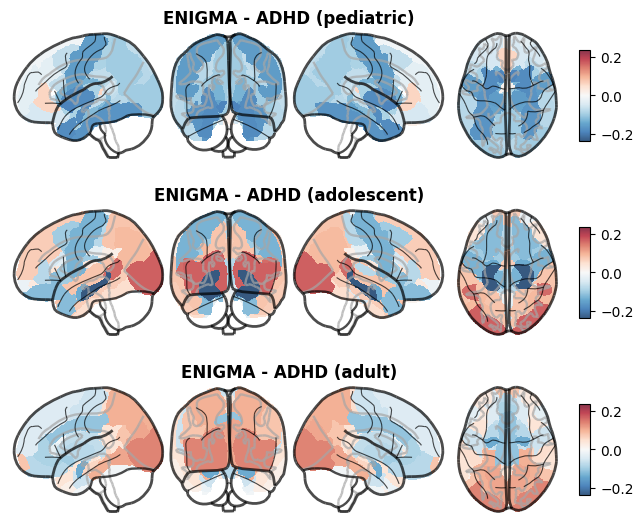

In [15]:
# shared color scale across multiple maps
# using the enigma dataset for illustration
enigma_data = fetch_reference("enigmathick", parcellation="DesikanAseg")

# select three maps based on index
enigma_data_to_plot = enigma_data.loc[[
    "dx-adhd_age-pediatric_pub-hoogman2019", 
    "dx-adhd_age-adolescent_pub-hoogman2019", 
    "dx-adhd_age-adult_pub-hoogman2019"
]]

# plot
brainplot(
    enigma_data_to_plot,
    parcellation="DesikanAseg",
    symmetric_cmap=True,
    shared_colorscale=True,  # same scale for all maps
    ncols=1,
    title=["ENIGMA - ADHD (pediatric)", "ENIGMA - ADHD (adolescent)", "ENIGMA - ADHD (adult)"]
)

## Using `brainplot()` inside a larger figure

Pass `fig` and `axes` to embed the plot inside an existing matplotlib figure.

INFO | 23/05/26 10:55:57 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:55:57 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR
INFO | 23/05/26 10:55:57 | nispace.core.parcellation: Parcellation 'Schaefer200': validation passed.
INFO | 23/05/26 10:55:57 | nispace.plotting: brainplot: threshold='auto' → 0.02822890877723694
INFO | 23/05/26 10:55:57 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 23/05/26 10:55:57 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym'.
INFO | 23/05/26 10:55:57 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'
INFO | 23/05/26 10:56:02 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200' from library.
INFO | 23/05/26 10:56:02 | nispace

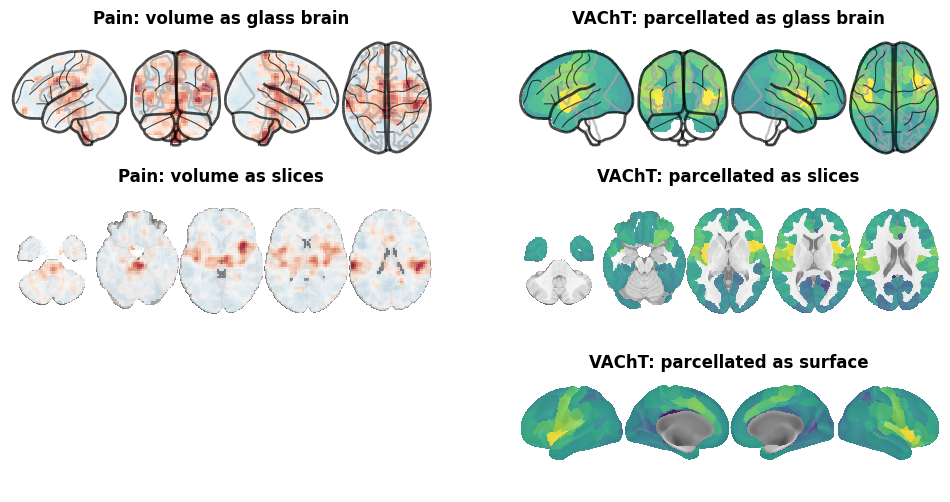

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(12, 6))

# column 1: pain map
brainplot(pain_map, kind="glass", fig=fig, axes=axes[0,0],
          title="Pain: volume as glass brain", colorbar=False)
brainplot(pain_map, kind="slice", fig=fig, axes=axes[1,0], cut_coords=[-40, -20, 0, 10, 20],
          title="Pain: volume as slices", colorbar=False)
axes[2,0].set_axis_off()

# columns 2: parcellated VAChT 
brainplot(vacht, parcellation="Schaefer200", kind="glass",
          symmetric_cmap=False, fig=fig, axes=axes[0,1],
          title="VAChT: parcellated as glass brain", colorbar=False)
brainplot(vacht, parcellation="Schaefer200", kind="slice", cut_coords=[-40, -20, 0, 10, 20],
          symmetric_cmap=False, fig=fig, axes=axes[1,1],
          title="VAChT: parcellated as slices", colorbar=False)
brainplot(vacht, parcellation="Schaefer200", kind="surface",
          symmetric_cmap=False, fig=fig, axes=axes[2,1],
          title="VAChT: parcellated as surface", colorbar=False)

plt.show()

## Plot a parcellation via the Parcellation class

The `Parcellation` class also uses `brainplot` to generate plots.

/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_10448/4004943157.py:5: DeprecationWarning: Starting in version 0.13, the default fetched mask will beAAL 3v2 instead.
  parc = Parcellation.from_path(fetch_atlas_aal().maps)


[fetch_atlas_aal] Dataset found in /Users/llotter/nilearn_data/aal_SPM12
INFO | 23/05/26 10:56:13 | nispace.core.parcellation: Building Parcellation from path / image.
INFO | 23/05/26 10:56:13 | nispace.core.parcellation: Parcellation space: 'mni152'.
INFO | 23/05/26 10:56:13 | nispace.core.parcellation: Parcellation 'None': validation passed.


(<Figure size 720x180 with 5 Axes>, [<Axes: >])

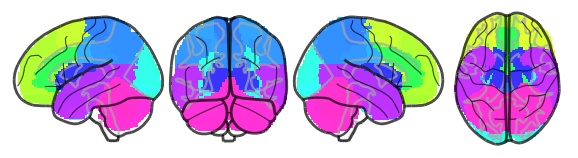

In [17]:
from nispace.core.parcellation import Parcellation
from nilearn.datasets import fetch_atlas_aal

# create the Parcellation object from a file path
parc = Parcellation.from_path(fetch_atlas_aal().maps)

# plot
parc.plot()

## Summary

**`brainplot()` key arguments:**

| Argument | What it does |
|----------|--------------|
| `data` | NIfTI image, GIfTI pair, DataFrame, or Series |
| `parcellation` | Required when `data` is tabular; a NiSpace name, file path, or image |
| `kind` | `"glass"`, `"slice"`, `"surface"`, `"combined"` |
| `cmap` | Any matplotlib colormap |
| `symmetric_cmap` | Zero-centered scale |
| `vmin`, `vmax` | Manual scale limits |
| `shared_colorscale` | Same scale across all maps in a DataFrame |
| `ncols` | Grid layout for multiple maps |
| `fig`, `axes` | Embed in existing matplotlib figure |

Next: [Notebook 9](intro9_workflows.ipynb) covers NiSpace's one-call workflow functions — the fastest way to run standard pipelines.